Import Libraries

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

2.21.0
TensorFlow Version: 2.21.0


Load Dataset

In [2]:
df = pd.read_csv("C:\\Users\\SUMIT\\Downloads\\TSLA.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


Dataset Information

In [3]:
print(df.shape)

df.info()

df.describe()

(2416, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


Convert Date Column

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df.sort_values('Date', inplace=True)

df.reset_index(drop=True, inplace=True)

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


Missing Values

In [5]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Handle Missing Values

In [6]:
df.fillna(method='ffill', inplace=True)

df.fillna(method='bfill', inplace=True)

df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Visualize Closing Price

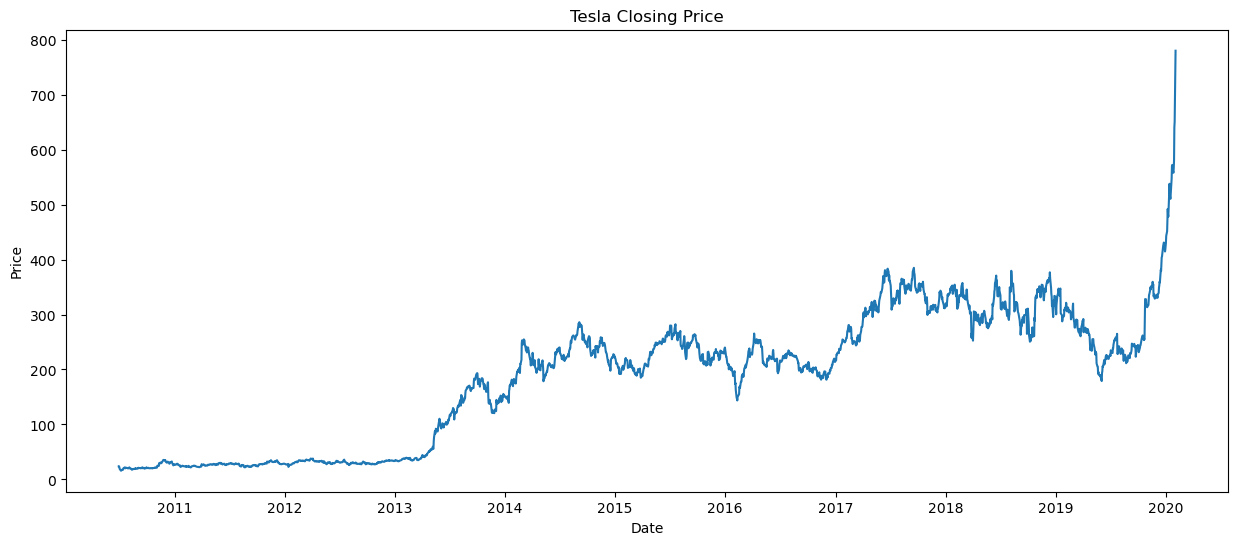

In [7]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Close'])

plt.title('Tesla Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

Volume Trend

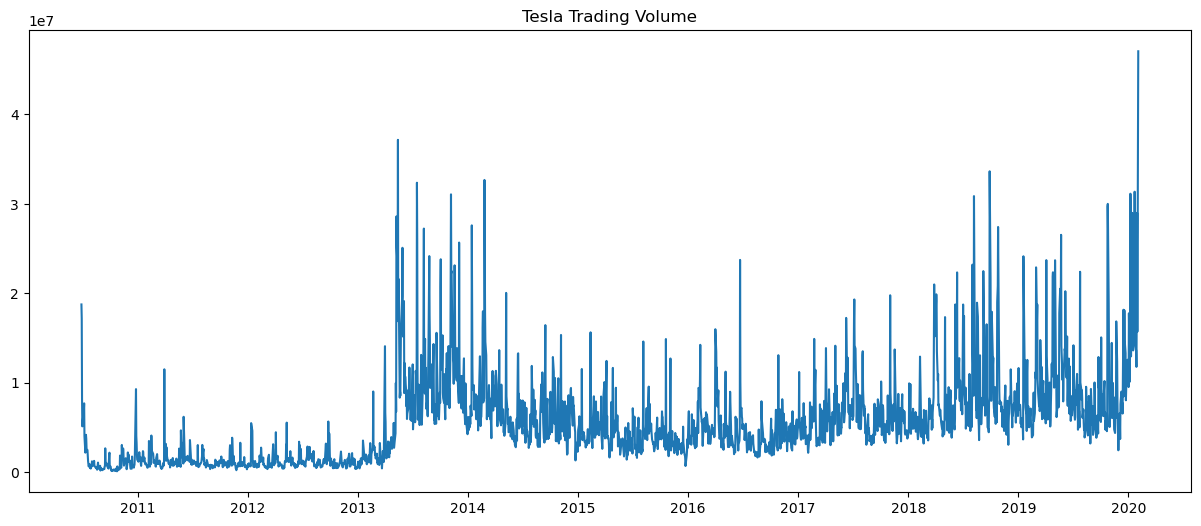

In [8]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Volume'])

plt.title("Tesla Trading Volume")

plt.show()

Scatter Plot (Volume vs Close)

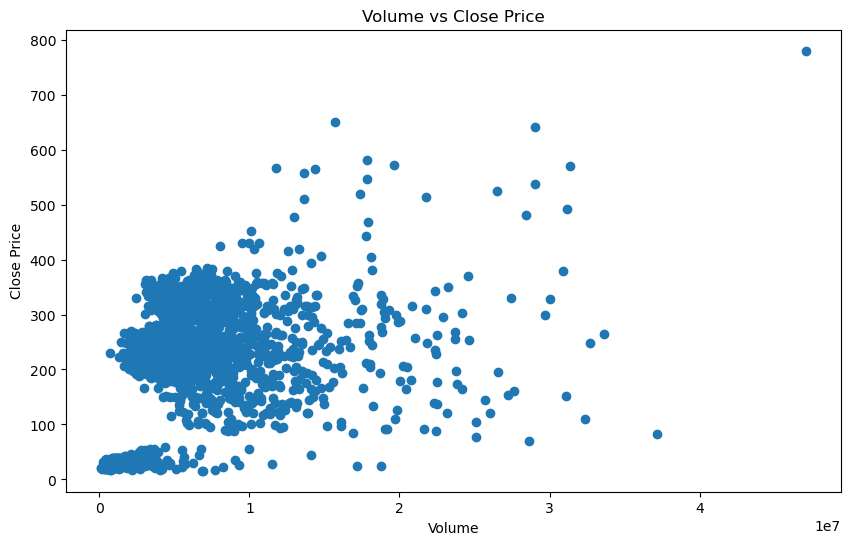

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Volume'],
    df['Close']
)

plt.title("Volume vs Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")

plt.show()

Scatter Plot (Open vs Close)

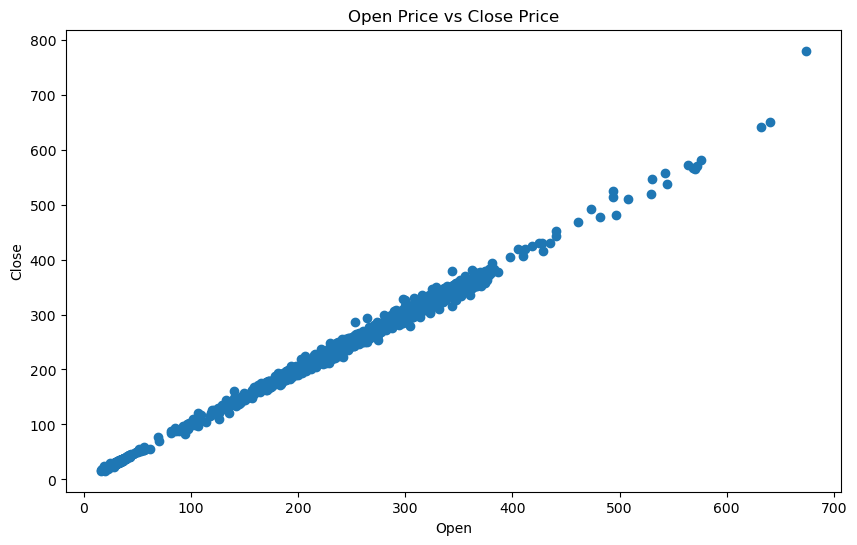

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Open'],
    df['Close']
)

plt.title("Open Price vs Close Price")
plt.xlabel("Open")
plt.ylabel("Close")

plt.show()

Bar Chart (Monthly Average Closing Price)

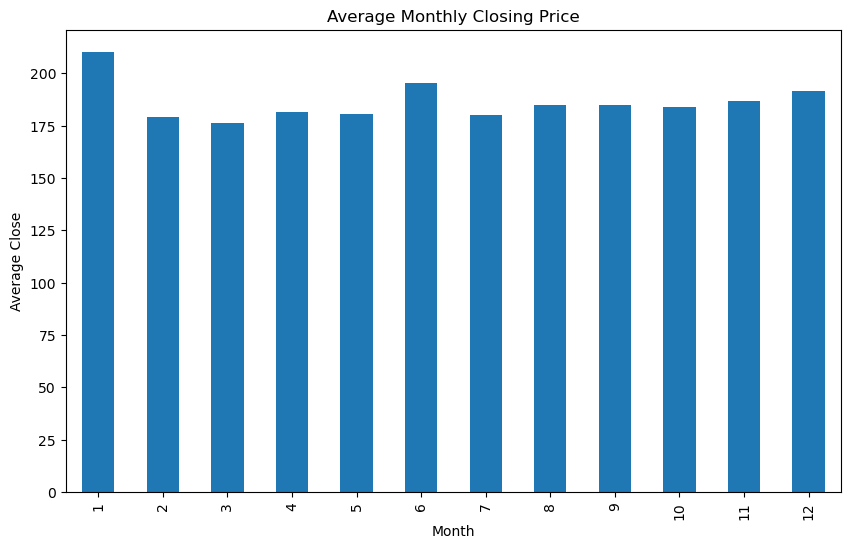

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_avg = (
    df.groupby(df['Date'].dt.month)
    ['Close']
    .mean()
)

monthly_avg.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average Monthly Closing Price")

plt.xlabel("Month")
plt.ylabel("Average Close")

plt.show()

Horizontal Bar Chart

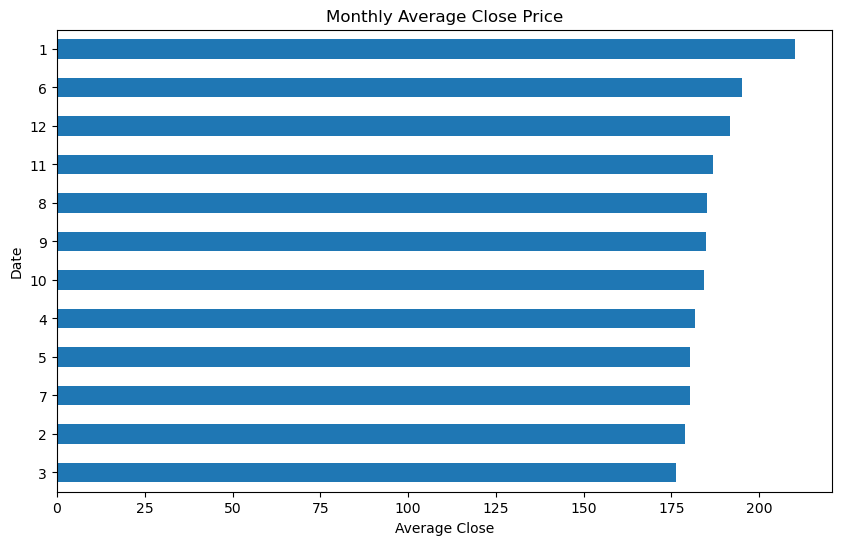

In [12]:
monthly_avg.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Monthly Average Close Price")

plt.xlabel("Average Close")

plt.show()

Histogram of Closing Price

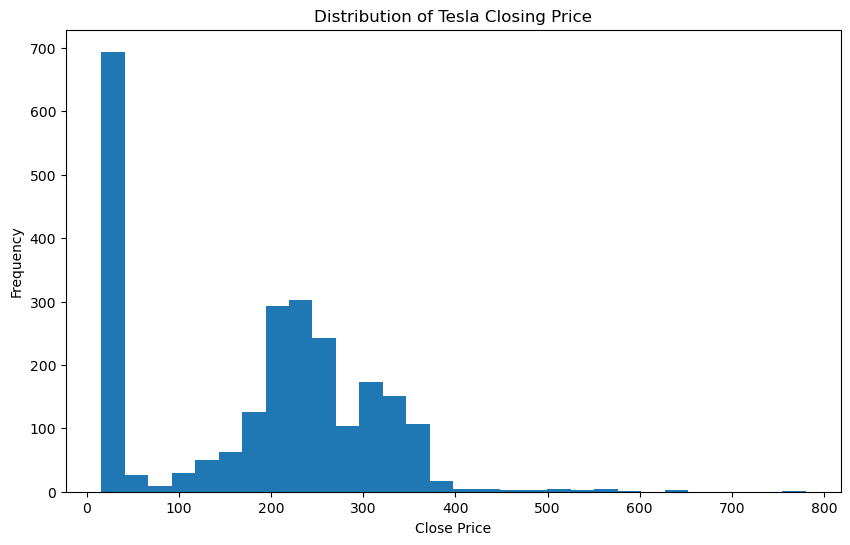

In [13]:
plt.figure(figsize=(10,6))

plt.hist(df['Close'], bins=30)

plt.title("Distribution of Tesla Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

Box Plot

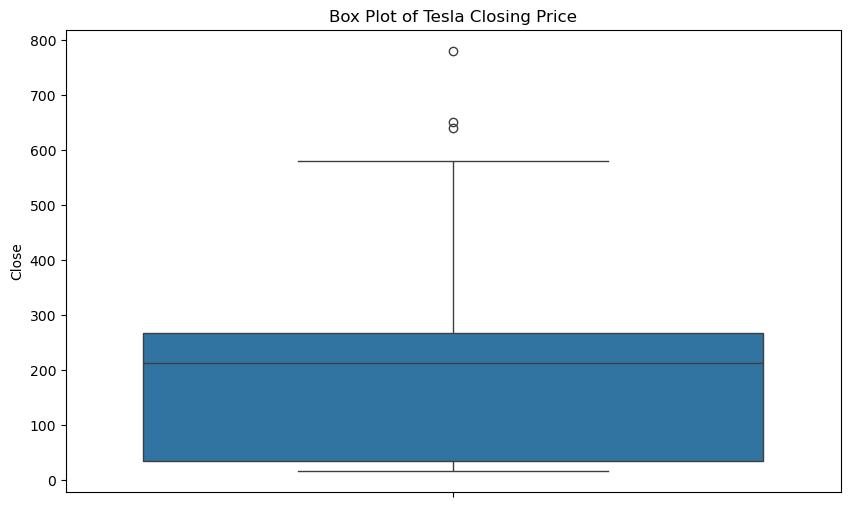

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df['Close']
)

plt.title("Box Plot of Tesla Closing Price")

plt.show()

Box Plot for All Numerical Features

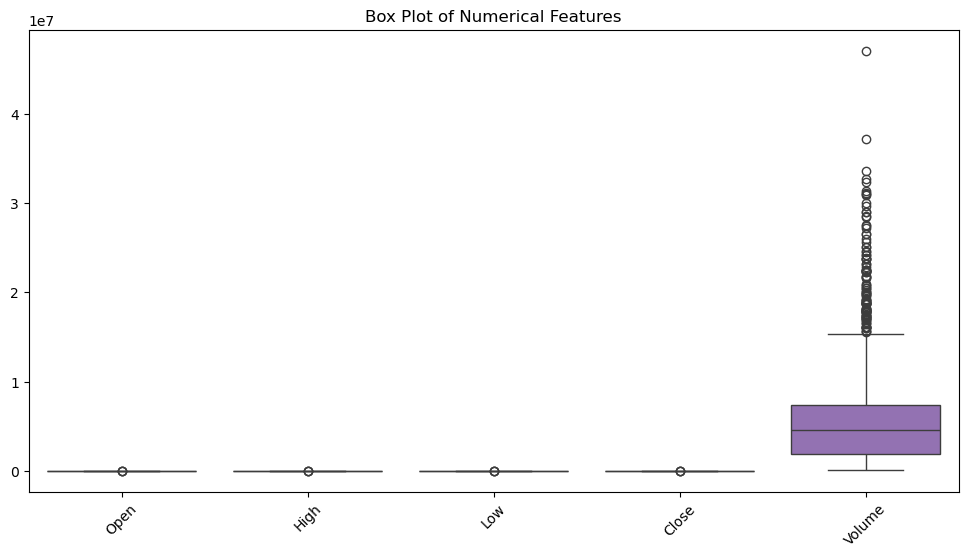

In [15]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[
        ['Open',
         'High',
         'Low',
         'Close',
         'Volume']
    ]
)

plt.xticks(rotation=45)

plt.title("Box Plot of Numerical Features")

plt.show()

Violin Plot

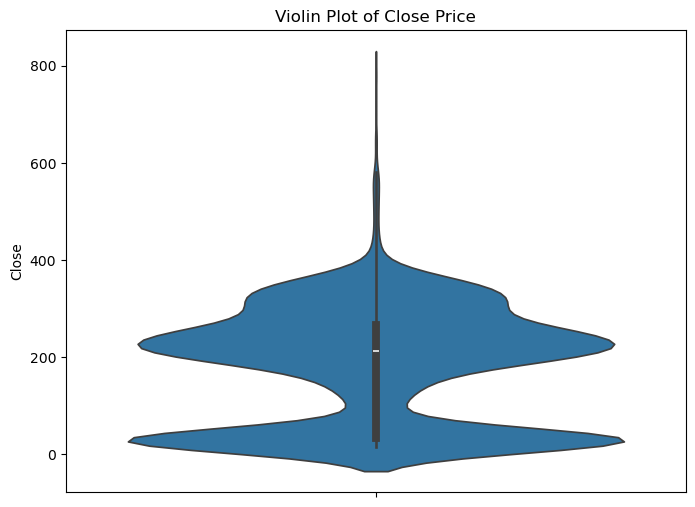

In [16]:
plt.figure(figsize=(8,6))

sns.violinplot(
    y=df['Close']
)

plt.title("Violin Plot of Close Price")

plt.show()

KDE Distribution Plot

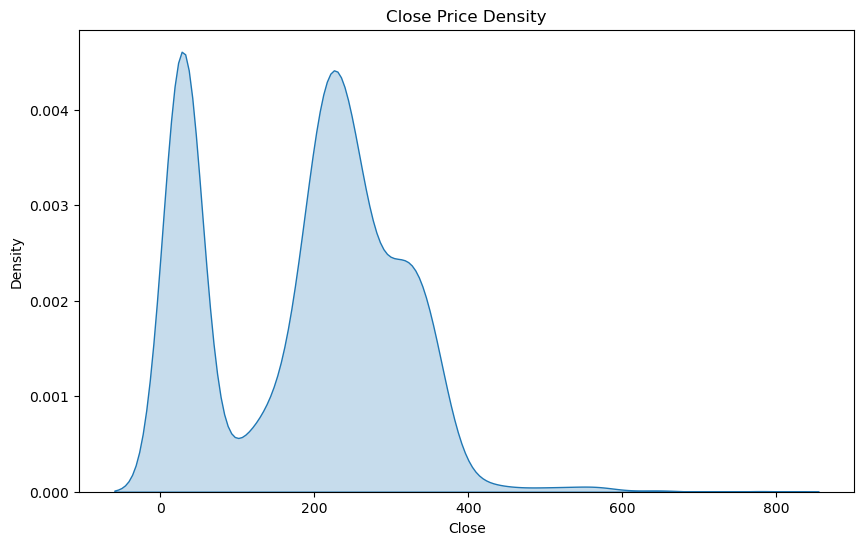

In [17]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['Close'],
    fill=True
)

plt.title("Close Price Density")

plt.show()

Pie Chart: Quarterly Average Trading Volume

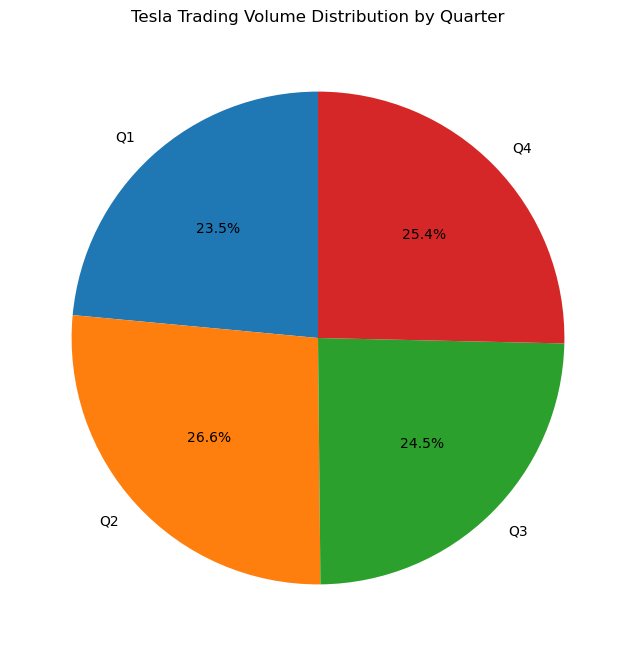

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

df['Quarter'] = df['Date'].dt.quarter

quarter_volume = df.groupby('Quarter')['Volume'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    quarter_volume,
    labels=[f'Q{i}' for i in quarter_volume.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Tesla Trading Volume Distribution by Quarter")

plt.savefig(
    "../outputs/visualizations/quarterly_volume_pie_chart.png"
)

plt.show()

Donut Chart (Digital Pie Chart)

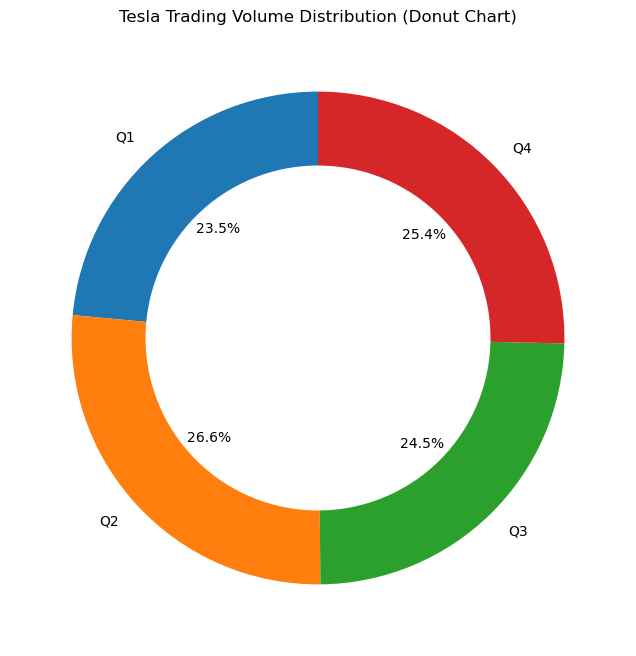

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    quarter_volume,
    labels=[f'Q{i}' for i in quarter_volume.index],
    autopct='%1.1f%%',
    startangle=90
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Tesla Trading Volume Distribution (Donut Chart)")

plt.savefig(
    "../outputs/visualizations/quarterly_volume_donut_chart.png"
)

plt.show()

Pie Chart: Distribution of Price Components

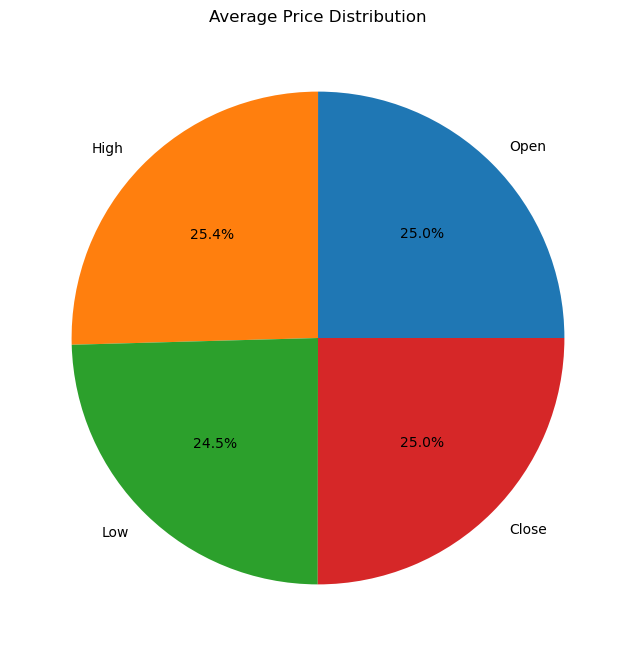

In [20]:
price_avg = [
    df['Open'].mean(),
    df['High'].mean(),
    df['Low'].mean(),
    df['Close'].mean()
]

labels = [
    'Open',
    'High',
    'Low',
    'Close'
]

plt.figure(figsize=(8,8))

plt.pie(
    price_avg,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Average Price Distribution")

plt.savefig(
    "../outputs/visualizations/price_distribution_pie.png"
)

plt.show()

Pair Plot

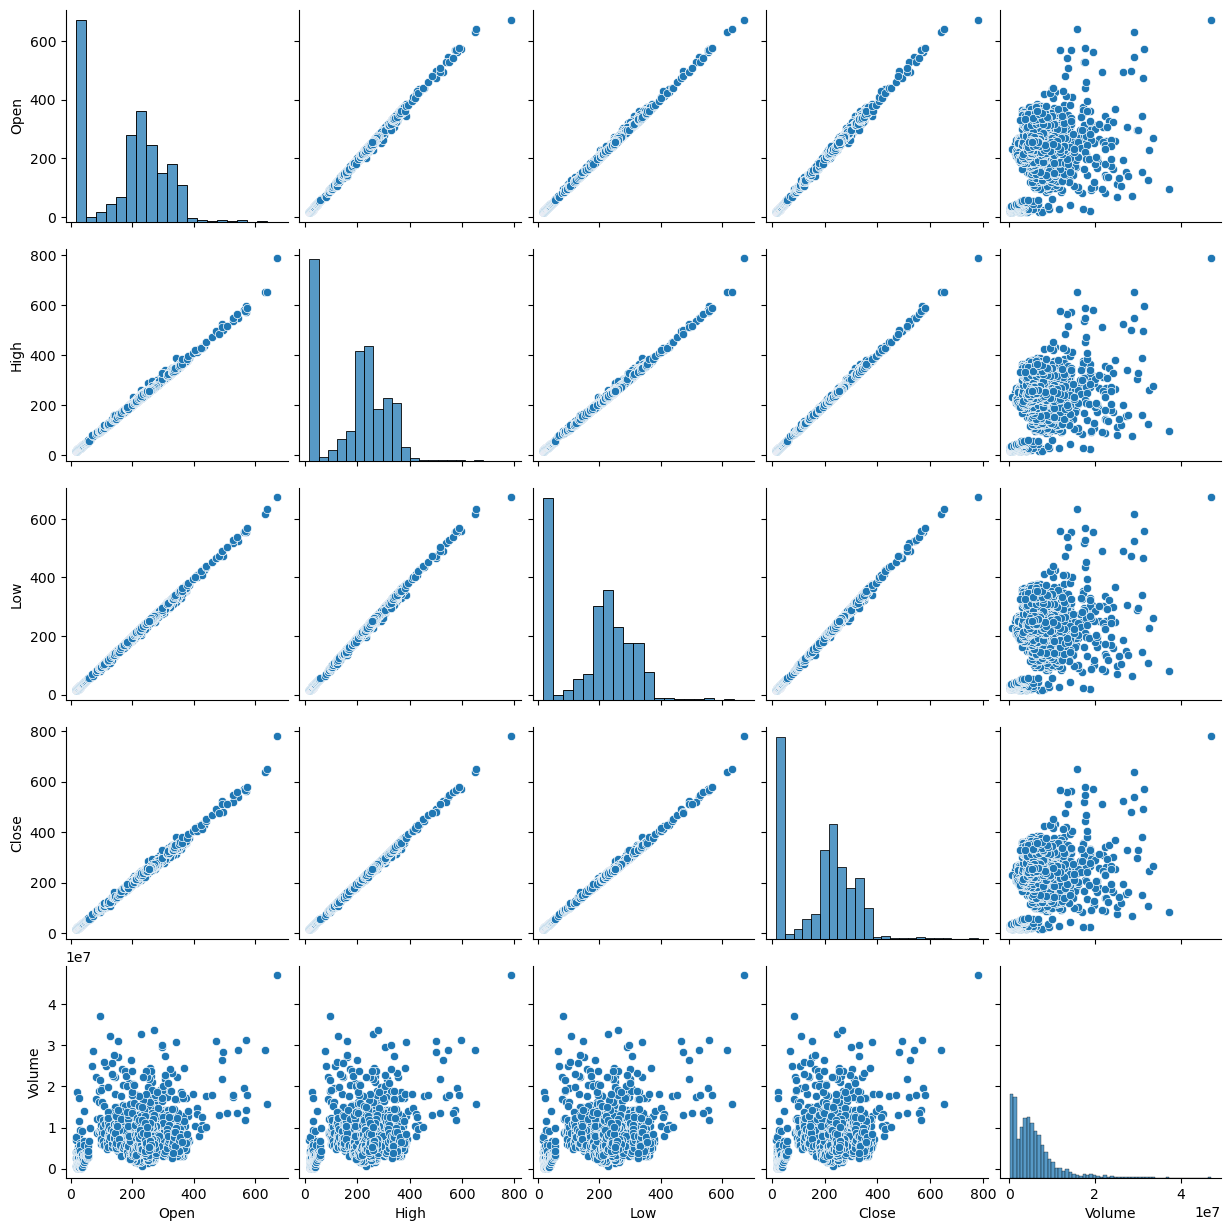

In [21]:
sns.pairplot(
    df[
        ['Open',
         'High',
         'Low',
         'Close',
         'Volume']
    ]
)

plt.show()

Correlation Heatmap

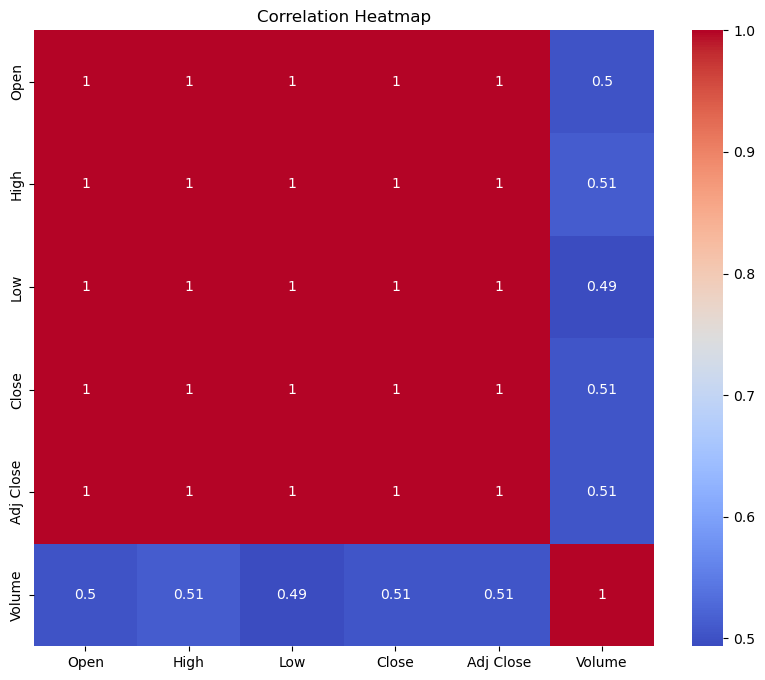

In [22]:
plt.figure(figsize=(10,8))

corr = df[
    ['Open',
     'High',
     'Low',
     'Close',
     'Adj Close',
     'Volume']
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Candlestick Style Visualization

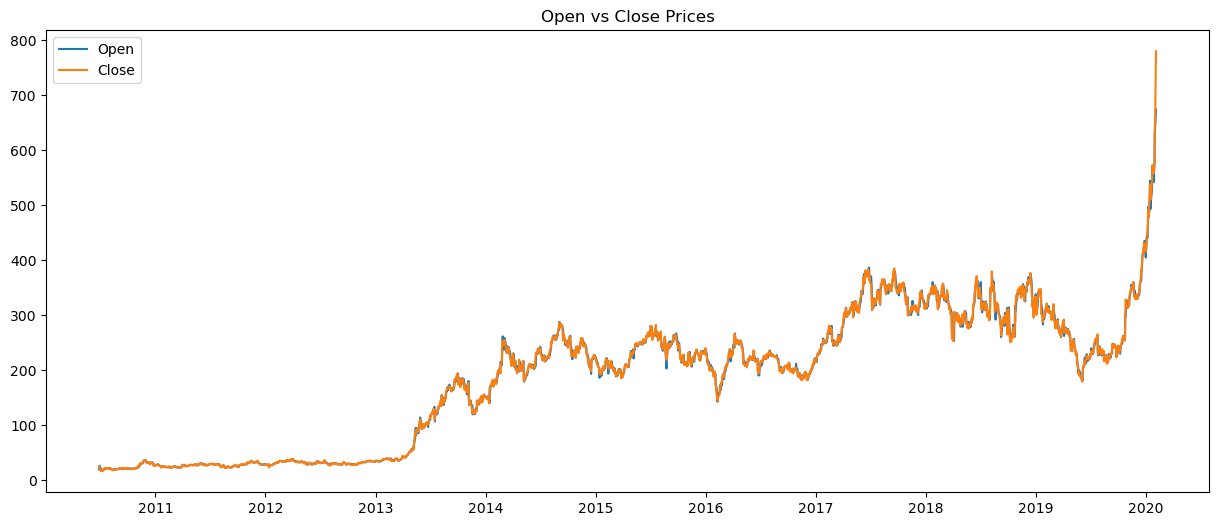

In [23]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'],df['Open'],label='Open')
plt.plot(df['Date'],df['Close'],label='Close')

plt.legend()

plt.title("Open vs Close Prices")

plt.show()

Rolling Moving Average

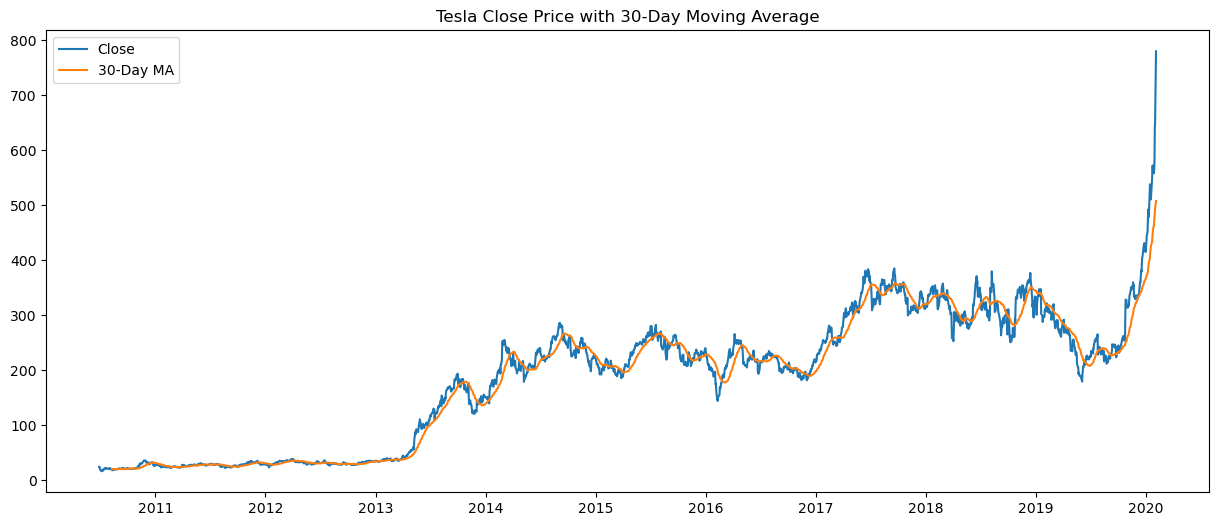

In [24]:
df['MA30'] = (
    df['Close']
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Close'],
    label='Close'
)

plt.plot(
    df['Date'],
    df['MA30'],
    label='30-Day MA'
)

plt.legend()

plt.title("Tesla Close Price with 30-Day Moving Average")

plt.show()

Daily Returns

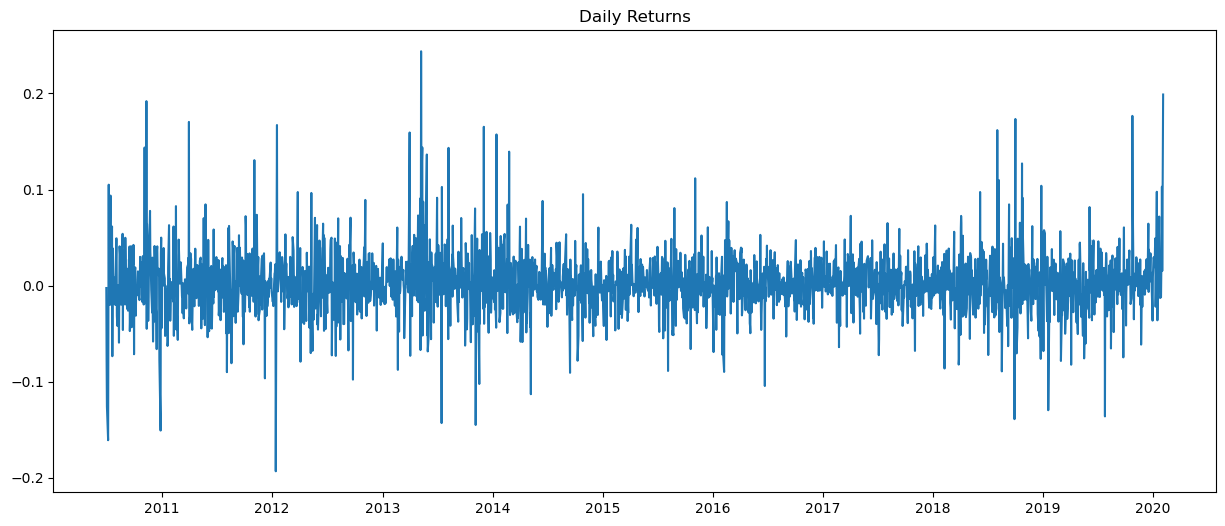

In [25]:
df['Daily_Return'] = (
    df['Close']
    .pct_change()
)

plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Daily_Return']
)

plt.title("Daily Returns")

plt.show()

Volume Distribution

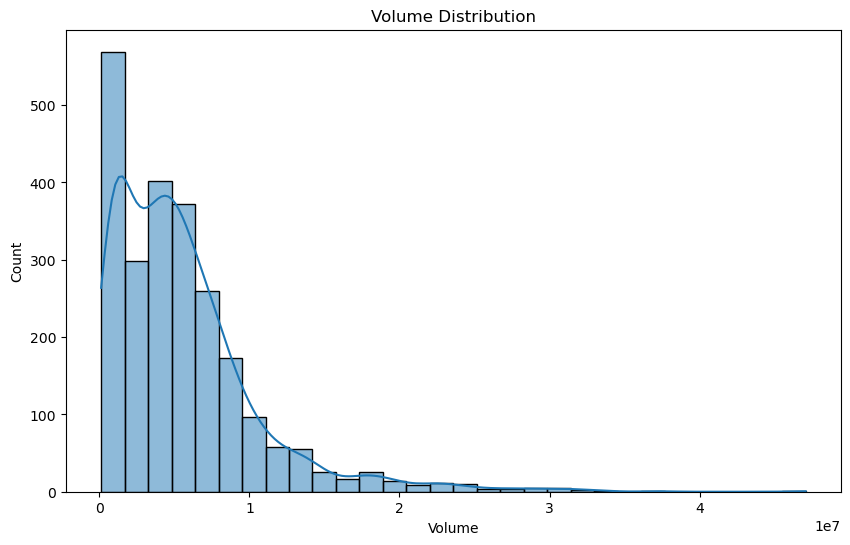

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Volume'],
    bins=30,
    kde=True
)

plt.title("Volume Distribution")

plt.show()

Joint Plot

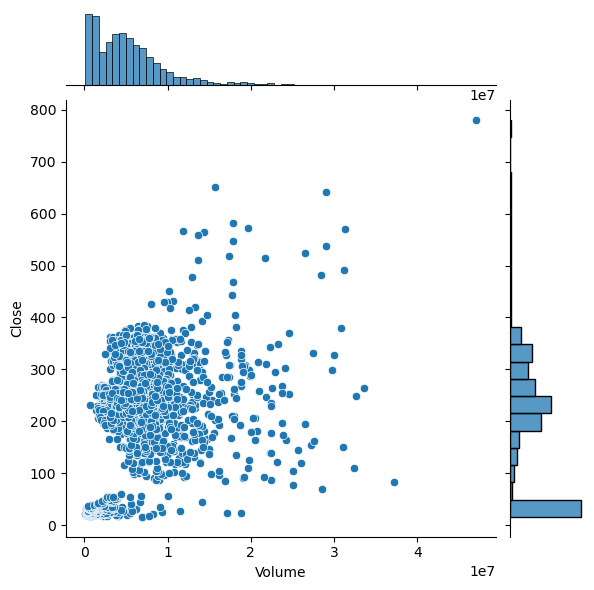

In [27]:
sns.jointplot(
    data=df,
    x='Volume',
    y='Close',
    kind='scatter'
)

plt.show()

Missing Value Heatmap

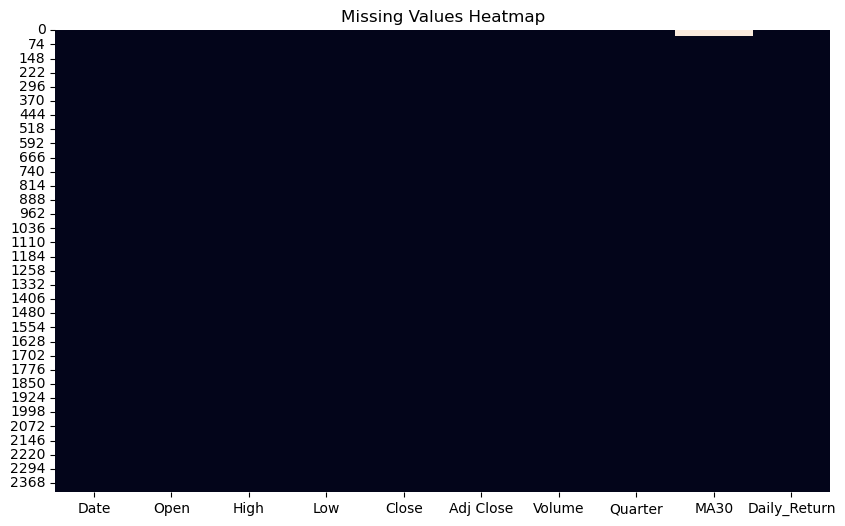

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

Feature Correlation with Close Price

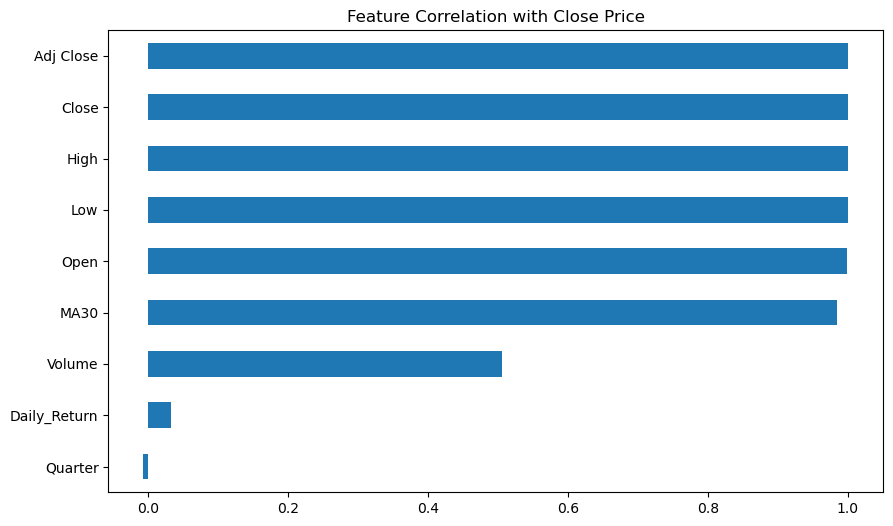

In [29]:
corr_close = (
    df.corr(numeric_only=True)
    ['Close']
    .sort_values()
)

corr_close.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Correlation with Close Price")

plt.show()

Select Target Feature

In [30]:
close_data = df[['Close']]
close_data.head()

,Close
0,23.889999
1,23.830000
2,21.959999
3,19.200001
4,16.110001


Scaling

In [31]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(close_data)

scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

Create Sequence Function

In [32]:
def create_dataset(dataset, look_back=60, forecast_days=1):

    X = []
    y = []

    for i in range(len(dataset)-look_back-forecast_days+1):

        X.append(dataset[i:i+look_back,0])

        y.append(
            dataset[
                i+look_back:i+look_back+forecast_days,
                0
            ]
        )

    return np.array(X), np.array(y)

Create Dataset for 1-Day Prediction

In [33]:
LOOK_BACK = 60

X, y = create_dataset(
    scaled_data,
    look_back=LOOK_BACK,
    forecast_days=1
)

print(X.shape)
print(y.shape)

(2356, 60)
(2356, 1)


Train Test Split

In [34]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(1884, 60)
(472, 60)


Reshape for RNN

In [35]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

Build SimpleRNN Model

In [36]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(LOOK_BACK,1)
    )
)

rnn_model.add(Dense(25))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,901 (15.24 KB)

 Trainable params: 3,901 (15.24 KB)

 Non-trainable params: 0 (0.00 B)

Train SimpleRNN

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.2616e-04 - val_loss: 2.5032e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 9.2508e-05 - val_loss: 2.2459e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.9411e-05 - val_loss: 2.3018e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.3331e-05 - val_loss: 1.9849e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.1053e-05 - val_loss: 2.0343e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.3485e-05 - val_loss: 1.8445e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.4453e-05 - val_loss: 1.7815e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.2917e-05 - val_loss: 2.7381e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.8120e-05 - val_loss: 1.6676e-04
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.2937e-05 - val_

Train SimpleRNN

In [38]:
rnn_predictions = rnn_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


Inverse Transform

In [39]:
rnn_predictions = scaler.inverse_transform(
    rnn_predictions
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

Evaluate RNN

In [40]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        rnn_predictions
    )
)

mae = mean_absolute_error(
    actual,
    rnn_predictions
)

r2 = r2_score(
    actual,
    rnn_predictions
)

print("RNN RMSE :", rmse)
print("RNN MAE :", mae)
print("RNN R2 :", r2)

RNN RMSE : 13.195117105730638
RNN MAE : 8.090260378529694
RNN R2 : 0.9669571383122743


Plot RNN Results

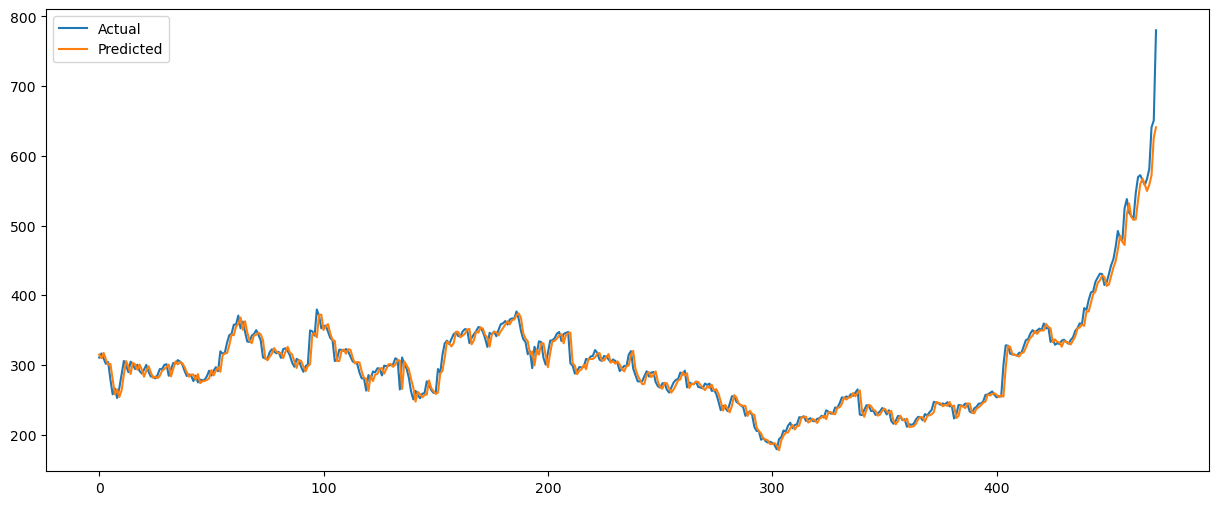

In [41]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual')

plt.plot(
    rnn_predictions,
    label='Predicted'
)

plt.legend()

plt.show()

Build LSTM Model

In [42]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        100,
        return_sequences=True,
        input_shape=(LOOK_BACK,1)
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    LSTM(100)
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(Dense(25))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,751 (483.40 KB)

 Trainable params: 123,751 (483.40 KB)

 Non-trainable params: 0 (0.00 B)

Train LSTM

In [43]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0021 - val_loss: 5.0176e-04
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 3.7226e-04 - val_loss: 4.4717e-04
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 3.2527e-04 - val_loss: 4.7401e-04
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - loss: 3.1659e-04 - val_loss: 3.8135e-04
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 3.2432e-04 - val_loss: 8.2686e-04
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 2.7799e-04 - val_loss: 3.4970e-04
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 2.7268e-04 - val_loss: 5.9272e-04
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 2.2889e-04 - val_loss: 5.1498e-04
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 2.4506e-04 - val_loss: 5.2661e-04
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - loss: 2.0941e-04 - val_loss: 3.5709e-04


Predict LSTM

In [44]:
lstm_predictions = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step


Inverse Transform

In [45]:
lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

Evaluate LSTM

In [46]:
rmse = np.sqrt(
    mean_squared_error(
        actual,
        lstm_predictions
    )
)

mae = mean_absolute_error(
    actual,
    lstm_predictions
)

r2 = r2_score(
    actual,
    lstm_predictions
)

print("LSTM RMSE :", rmse)
print("LSTM MAE :", mae)
print("LSTM R2 :", r2)

LSTM RMSE : 29.60129161631574
LSTM MAE : 20.190466929410256
LSTM R2 : 0.8337075708332717


Plot LSTM Results

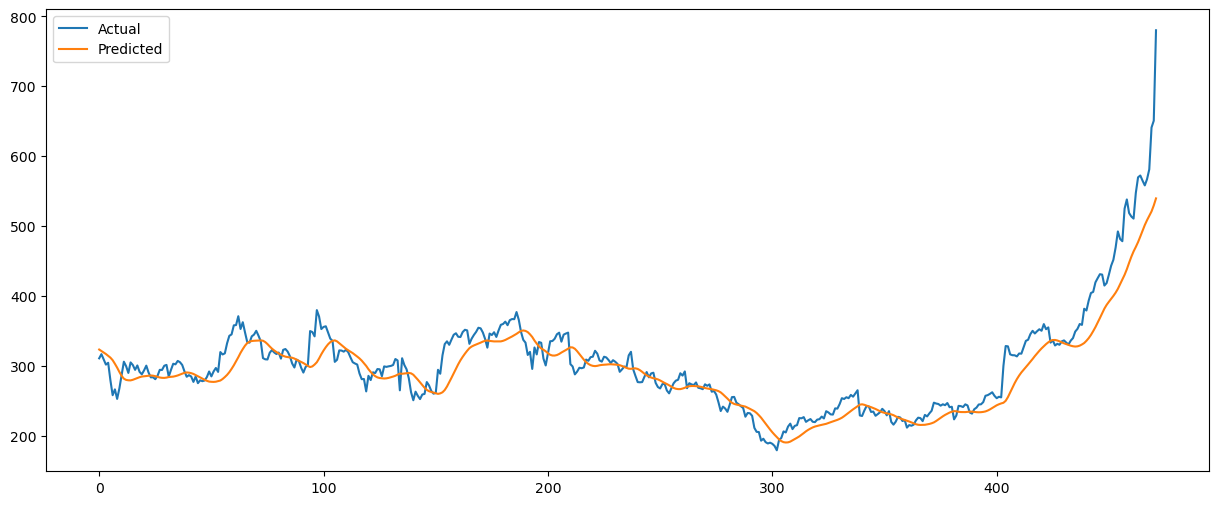

In [47]:
plt.figure(figsize=(15,6))

plt.plot(actual,label='Actual')

plt.plot(
    lstm_predictions,
    label='Predicted'
)

plt.legend()

plt.show()

Save Models

In [48]:
import os
print(os.getcwd())

os.path.exists("../models")
os.makedirs("../models", exist_ok=True)
rnn_model.save("../models/best_rnn.keras")
lstm_model.save("../models/best_lstm.keras")


rnn_model.save(
    "..//models//best_rnn.keras"
)

lstm_model.save(
    "..//models//best_lstm.keras"
)

c:\Users\SUMIT\OneDrive\Dokumen\Tesla-Stock-Price-Prediction-DL\notebook


Save Scaler

In [49]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

5-Day Prediction Model

In [50]:
X5, y5 = create_dataset(
    scaled_data,
    look_back=60,
    forecast_days=5
)

print(X5.shape)
print(y5.shape)

(2352, 60)
(2352, 5)


10-Day Prediction Model

In [51]:
X10, y10 = create_dataset(
    scaled_data,
    look_back=60,
    forecast_days=10
)

print(X10.shape)
print(y10.shape)

(2347, 60)
(2347, 10)


Hyperparameter Tuning (LSTM)

In [52]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [53]:
!pip --version

pip 25.3 from C:\ProgramData\anaconda3\Lib\site-packages\pip (python 3.13)



In [54]:
import sys
!{sys.executable} -m pip install scikeras

Defaulting to user installation because normal site-packages is not writeable


In [55]:
from scikeras.wrappers import KerasRegressor

In [56]:
import pkg_resources

packages = [pkg.key for pkg in pkg_resources.working_set]

print("scikeras" in packages)

True


In [57]:
import sys
print(sys.version)

import tensorflow as tf
print(tf.__version__)

import sklearn
print(sklearn.__version__)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
2.21.0
1.7.2


In [58]:
!pip show scikeras

Name: scikeras
Version: 0.13.0
Summary: Scikit-Learn API wrapper for Keras.
Home-page: https://github.com/adriangb/scikeras
Author: Adrian Garcia Badaracco
Author-email: 1755071+adriangb@users.noreply.github.com
License: MIT
Location: C:\Users\SUMIT\AppData\Roaming\Python\Python313\site-packages
Requires: keras, scikit-learn
Required-by: 


In [59]:
! pip install keras-tuner

Defaulting to user installation because normal site-packages is not writeable


In [60]:
# Hyperparameter Tuning for LSTM

units_list = [50, 100]
dropout_list = [0.1, 0.2]
batch_sizes = [16, 32]

best_loss = float("inf")
best_params = {}

results = []

for units in units_list:
    for dropout in dropout_list:
        for batch_size in batch_sizes:

            print(
                f"Training -> Units:{units}, "
                f"Dropout:{dropout}, "
                f"Batch Size:{batch_size}"
            )

            model = Sequential()

            model.add(
                LSTM(
                    units=units,
                    input_shape=(60, 1)
                )
            )

            model.add(
                Dropout(dropout)
            )

            model.add(
                Dense(1)
            )

            model.compile(
                optimizer='adam',
                loss='mse'
            )

            history = model.fit(
                X_train,
                y_train,
                validation_split=0.1,
                epochs=20,
                batch_size=batch_size,
                verbose=0
            )

            val_loss = min(
                history.history['val_loss']
            )

            results.append({
                "units": units,
                "dropout": dropout,
                "batch_size": batch_size,
                "val_loss": val_loss
            })

            if val_loss < best_loss:
                best_loss = val_loss

                best_params = {
                    "units": units,
                    "dropout": dropout,
                    "batch_size": batch_size
                }

print("\nBest Parameters:")
print(best_params)

print("\nBest Validation Loss:")
print(best_loss)

Training -> Units:50, Dropout:0.1, Batch Size:16
Training -> Units:50, Dropout:0.1, Batch Size:32
Training -> Units:50, Dropout:0.2, Batch Size:16
Training -> Units:50, Dropout:0.2, Batch Size:32
Training -> Units:100, Dropout:0.1, Batch Size:16
Training -> Units:100, Dropout:0.1, Batch Size:32
Training -> Units:100, Dropout:0.2, Batch Size:16
Training -> Units:100, Dropout:0.2, Batch Size:32

Best Parameters:
{'units': 100, 'dropout': 0.1, 'batch_size': 16}

Best Validation Loss:
0.0001903687953017652


In [61]:
# Create Output Folders
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
os.makedirs("../outputs/visualizations", exist_ok=True)
os.makedirs("../outputs/metrics", exist_ok=True)

print("Folders Created Successfully")

import pandas as pd
df = pd.read_csv("C:\\Users\\SUMIT\\Downloads\\TSLA.csv")   # or whatever the file you’re using now in your context

Folders Created Successfully


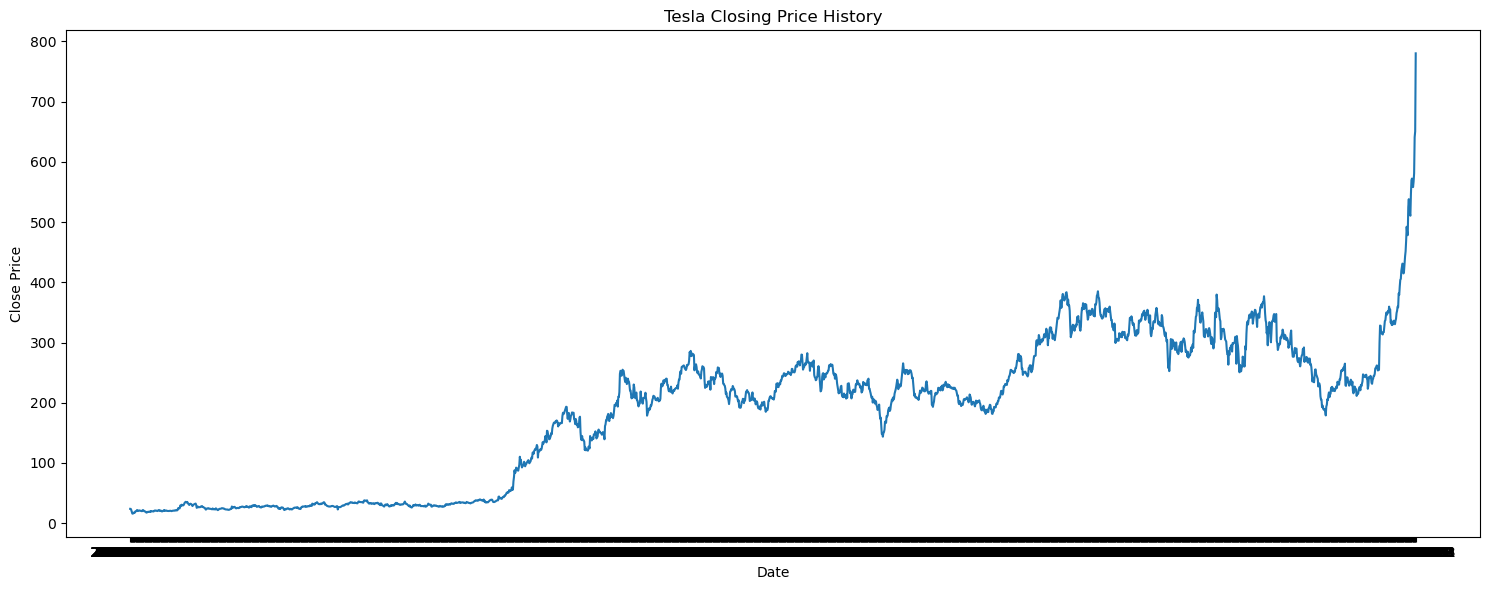

In [62]:

# Tesla Closing Price Visualization
plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Close']
)

plt.title("Tesla Closing Price History")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.tight_layout()

plt.savefig(
    "../outputs/visualizations/tesla_closing_price.png"
)

plt.show()

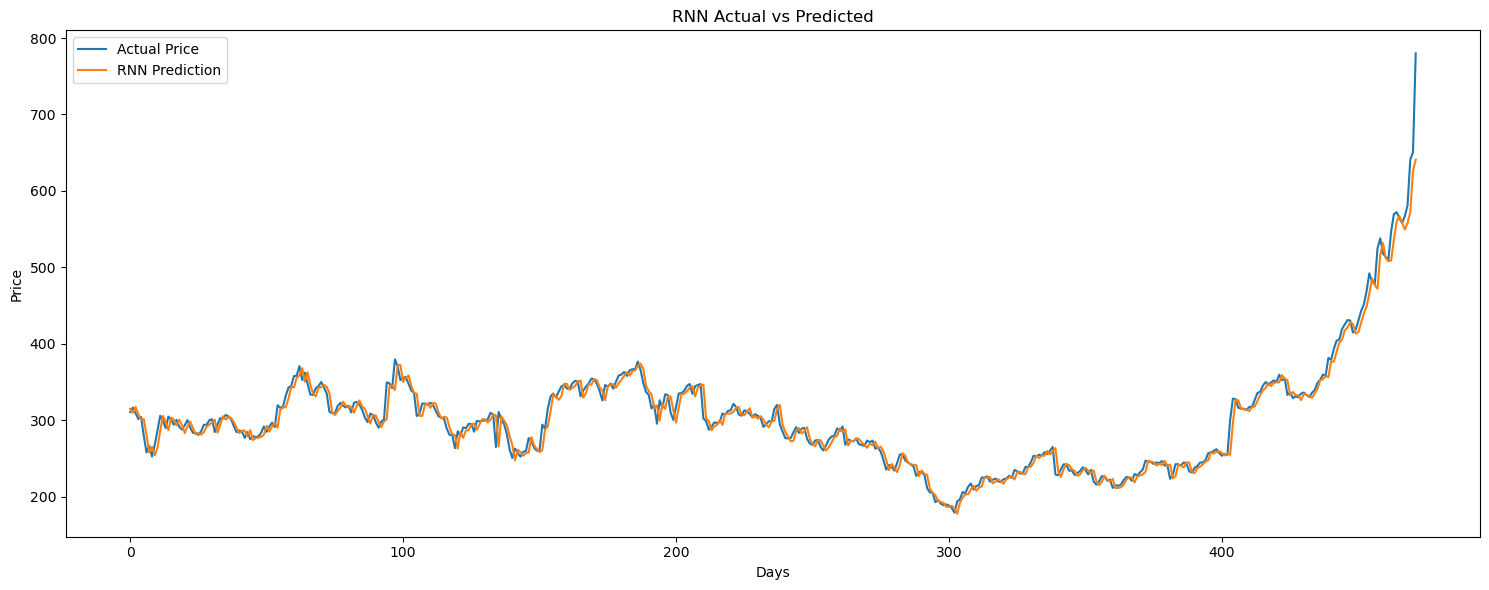

In [63]:

# RNN Actual vs Predicted

plt.figure(figsize=(15,6))

plt.plot(
    actual,
    label="Actual Price"
)

plt.plot(
    rnn_predictions,
    label="RNN Prediction"
)

plt.title("RNN Actual vs Predicted")

plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/visualizations/rnn_actual_vs_predicted.png"
)

plt.show()

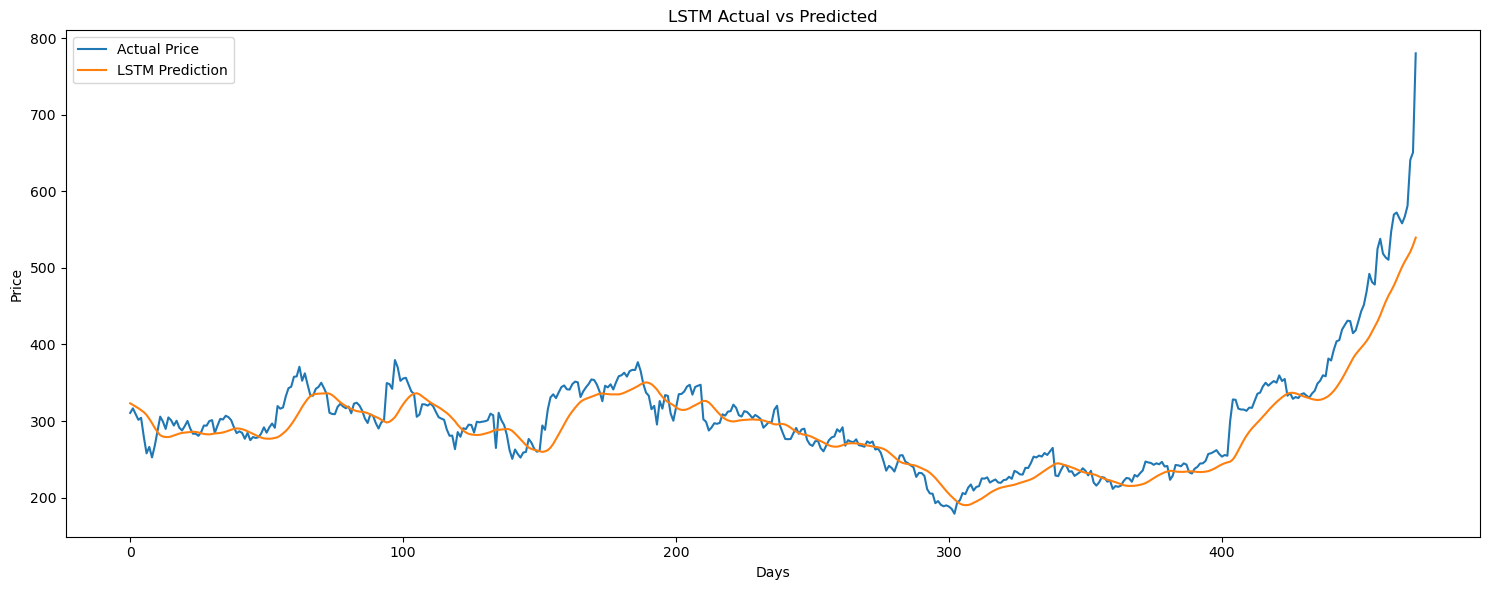

In [64]:

# LSTM Actual vs Predicted

plt.figure(figsize=(15,6))

plt.plot(
    actual,
    label="Actual Price"
)

plt.plot(
    lstm_predictions,
    label="LSTM Prediction"
)

plt.title("LSTM Actual vs Predicted")

plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/visualizations/lstm_actual_vs_predicted.png"
)

plt.show()

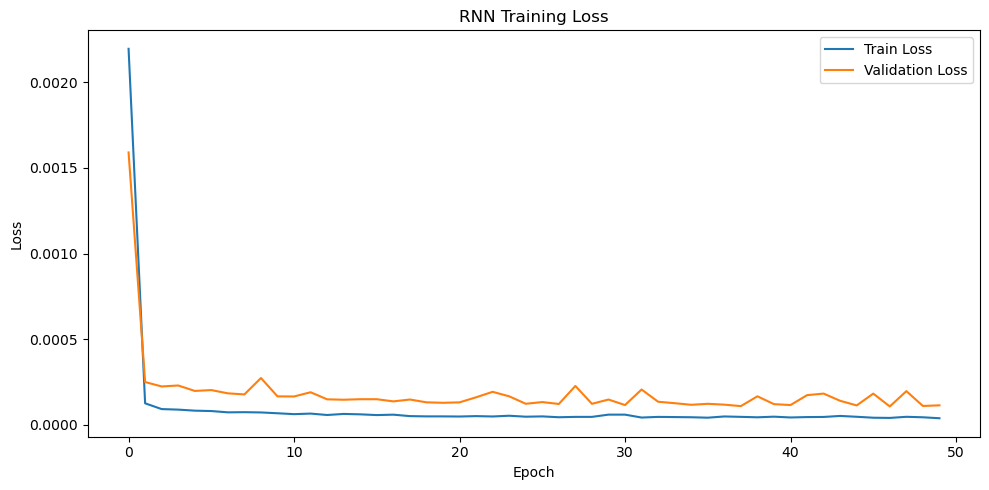

In [65]:
# RNN Training Loss

plt.figure(figsize=(10,5))

plt.plot(
    history_rnn.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/visualizations/training_loss_rnn.png"
)

plt.show()

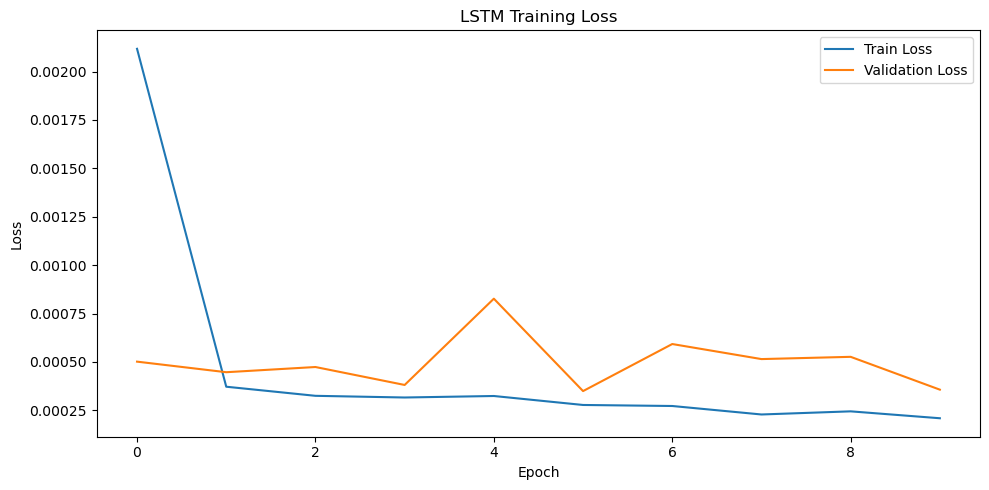

In [66]:
# LSTM Training Loss

plt.figure(figsize=(10,5))

plt.plot(
    history_lstm.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../outputs/visualizations/training_loss_lstm.png"
)

plt.show()

In [67]:
# RNN Metrics

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np
import pandas as pd

rnn_rmse = np.sqrt(
    mean_squared_error(
        actual,
        rnn_predictions
    )
)

rnn_mae = mean_absolute_error(
    actual,
    rnn_predictions
)

rnn_r2 = r2_score(
    actual,
    rnn_predictions
)

rnn_metrics = pd.DataFrame({
    "Metric":[
        "RMSE",
        "MAE",
        "R2 Score"
    ],
    "Value":[
        rnn_rmse,
        rnn_mae,
        rnn_r2
    ]
})

rnn_metrics.to_csv(
    "../outputs/metrics/rnn_metrics.csv",
    index=False
)

rnn_metrics

,Metric,Value
0,RMSE,13.195117
1,MAE,8.090260
2,R2 Score,0.966957


In [68]:
# LSTM Metrics

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual,
        lstm_predictions
    )
)

lstm_mae = mean_absolute_error(
    actual,
    lstm_predictions
)

lstm_r2 = r2_score(
    actual,
    lstm_predictions
)

lstm_metrics = pd.DataFrame({
    "Metric":[
        "RMSE",
        "MAE",
        "R2 Score"
    ],
    "Value":[
        lstm_rmse,
        lstm_mae,
        lstm_r2
    ]
})

lstm_metrics.to_csv(
    "../outputs/metrics/lstm_metrics.csv",
    index=False
)

lstm_metrics

,Metric,Value
0,RMSE,29.601292
1,MAE,20.190467
2,R2 Score,0.833708


In [69]:
# Model Comparison Table

comparison = pd.DataFrame({

    "Model":[
        "SimpleRNN",
        "LSTM"
    ],

    "RMSE":[
        rnn_rmse,
        lstm_rmse
    ],

    "MAE":[
        rnn_mae,
        lstm_mae
    ],

    "R2 Score":[
        rnn_r2,
        lstm_r2
    ]
})

comparison.to_csv(
    "../outputs/metrics/model_comparison.csv",
    index=False
)

comparison

,Model,RMSE,MAE,R2 Score
0,SimpleRNN,13.195117,8.090260,0.966957
1,LSTM,29.601292,20.190467,0.833708


In [70]:
# Display Best Model
best_model = comparison.loc[
    comparison['RMSE'].idxmin()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       SimpleRNN
RMSE        13.195117
MAE           8.09026
R2 Score     0.966957
Name: 0, dtype: object
